In [60]:
import yaml
from pathlib import Path
import pandas as pd

DEFAULT_CFG = Path("../household_energy/config_defaults.yaml") 
SCENARIO = Path("test_levers.yaml")  

def load_cfg(path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f) or {}

def save_cfg(path, data):
    with open(path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False)

# 1) Seed the scenario file from defaults if it doesn’t exist
if not SCENARIO.exists():
    cfg = load_cfg(DEFAULT_CFG)
    cfg["meta"]["name"] = "heat_pump_scenario"
    cfg["meta"]["date"] = pd.Timestamp.now().date().isoformat()
    cfg["meta"]["notes"] = "heat pump adoption scenario for testing, 30% adoption rate"
    save_cfg(SCENARIO, cfg)
    print(f"Created {SCENARIO}")

# 2) Edit in-memory, then save
cfg = load_cfg(SCENARIO)
cfg["model"]["apply_structural_multipliers"] = True  
cfg["systems"]["heat_pump"]["level_mult"] = 0.80    
cfg["archetypes"]["detached"]["ua_mult"] = 1.20    
cfg["model"]["heatpump_adoption_rate"] = 1  # 100% of eligible candidates

save_cfg(SCENARIO, cfg)
print(f"Updated {SCENARIO}")


Updated test_levers.yaml


In [61]:
import sys, os, importlib, pathlib, json, subprocess, shlex
from datetime import datetime
print(sys.version)
try:
    import household_energy
    print("household_energy package is importable ✅")
except Exception as e:
    print("household_energy not importable yet. If needed, run:")
    print("!pip install -e .")
    raise


3.12.1 (v3.12.1:2305ca5144, Dec  7 2023, 17:23:38) [Clang 13.0.0 (clang-1300.0.29.30)]
household_energy package is importable ✅


In [62]:
from pathlib import Path

#  --- data paths ---
GEOJSON = Path('../data/epc_abm_newcastle.geojson')
CLIMATE = Path('../data/ncc_2t_timeseries_2010_2039.parquet')
OUTDIR_QUICK = Path('results_quick')
OUTDIR_WIN   = Path('results_2020_2024')

for p in [GEOJSON, CLIMATE]:
    print(p, "exists:", p.exists())


../data/epc_abm_newcastle.geojson exists: True
../data/ncc_2t_timeseries_2010_2039.parquet exists: True


In [63]:
from household_energy.model import EnergyModel
from household_energy.climate import ClimateField
import pandas as pd
import geopandas as gpd
gdf = gpd.read_file(GEOJSON)

In [64]:
# Inspect columns first to confirm the right field
print(gdf.columns)

# Then list unique ward names
wards = gdf["ward_code"].dropna().unique()
print(f"Found {len(wards)} wards:")
for w in sorted(wards):
    print(" •", w)


Index(['UPRN', 'lsoa_code', 'local_authority', 'ward_code', 'habitable_rooms',
       'sap_rating', 'floor_area_m2', 'property_type', 'property_age',
       'main_fuel_type', 'main_heating_system', 'sap_band_ord',
       'retrofit_envelope_score', 'is_off_gas', 'energy_demand_kwh', 'factor',
       'energy_cal_kwh', 'is_heatpump_candidate', 'heatpump_candidate_class',
       'heating_controls', 'meter_type', 'cwi_flag', 'swi_flag',
       'loft_ins_flag', 'floor_ins_flag', 'glazing_flag',
       'is_electric_heating', 'is_gas', 'is_oil', 'is_solid_fuel',
       'epc_lodgement_date_year', 'geometry'],
      dtype='object')
Found 41 wards:
 • E05001068
 • E05001069
 • E05001074
 • E05001076
 • E05001081
 • E05001082
 • E05001143
 • E05011436
 • E05011437
 • E05011438
 • E05011439
 • E05011440
 • E05011441
 • E05011442
 • E05011443
 • E05011444
 • E05011445
 • E05011446
 • E05011447
 • E05011448
 • E05011449
 • E05011450
 • E05011451
 • E05011452
 • E05011453
 • E05011454
 • E05011455
 • 

In [65]:
ward_name = wards[2] # 🔧 pick your ward by name/code
gdf_small = gdf[gdf["ward_code"] == ward_name].copy()
gdf_small = (gdf_small.sort_values("epc_lodgement_date_year", ascending=False)
                     .drop_duplicates(subset="UPRN", keep="first"))
print(f"{len(gdf_small)} dwellings in {ward_name}")

4093 dwellings in E05011456


In [47]:
clim_path = CLIMATE  
cf = ClimateField(clim_path)
start_utc = pd.to_datetime(cf.times[0], utc=True)  # begin at climate start
print(start_utc)

m = EnergyModel(
    gdf=gdf_small,
    climate_parquet=clim_path,
    climate_start=start_utc,
    local_tz="Europe/London",
    collect_agent_level=True,   # keep per-household traces
    agent_collect_every=24,      # once per day,
    config_path=str(SCENARIO)
)


2020-01-01 00:00:00+00:00


/Users/abeltran/Documents/GitHub/spdt_abm/household_energy/model.py:226: RuntimeWarning: Mean of empty slice
  np.nanmean([getattr(h, "ambient_tempC", np.nan) for h in m.household_agents])


In [36]:
for h in range(24*7):   # e.g. 3 days
    m.step()

df_model = m.model_dc.get_model_vars_dataframe()
df_agent = m.agent_dc.get_agent_vars_dataframe()

print(df_model.head())
print(df_agent.head())


   mid-terraced house  semi-detached house  \
0            0.000000             0.000000   
1         1157.747838          3421.797616   
2         1155.364217          3413.899053   
3         1152.133015          3403.240481   
4         1164.521804          3445.139926   

   small block of flats/dwelling converted in to flats  large block of flats  \
0                                           0.000000                0.000000   
1                                        1172.974748              277.093622   
2                                        1168.576515              275.994986   
3                                        1162.644463              274.500777   
4                                        1186.029126              280.125292   

   block of flats  end-terraced house  detached house  \
0             0.0            0.000000        0.000000   
1             0.0          708.174208     5788.300912   
2             0.0          706.528758     5780.026360   
3             

In [48]:
df_model = m.model_dc.get_model_vars_dataframe()
df_model[["config_name", "config_date", "config_notes"]].head()



,config_name,config_date,config_notes
0,heat_pump_scenario,2025-11-18,"heat pump adoption scenario for testing, 30% a..."


In [49]:
m.config.model.get("apply_structural_multipliers")
m.config.systems.get("heat_pump", {})


{'level_mult': 0.8,
 'heating_slope_mult': 0.7,
 'cop_curve': [[15, 3.2], [7, 2.8], [0, 2.4], [-5, 2.0]]}

In [50]:
h0 = m.household_agents[0]
h0._hourly_base_kwh, h0.heat_slope_kWh_per_deg, h0.main_heating_system


(3.291056537150603, 0.11026314717719617, 'heat pump')

In [66]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
from household_energy.model import EnergyModel
from household_energy.climate import ClimateField

GEOJSON = Path("../data/epc_abm_newcastle.geojson")
CLIMATE = Path("../data/ncc_2t_timeseries_2010_2039.parquet")
T0 = pd.Timestamp("2020-01-01T00:00:00Z")
T1 = pd.Timestamp("2021-01-01T00:00:00Z")  # one year

gdf_small 
cf = ClimateField(CLIMATE)
n_hours = int((T1 - T0).total_seconds() // 3600)

def run_model(cfg_path, label):
    m = EnergyModel(
        gdf=gdf_small,
        climate_parquet=str(CLIMATE),
        climate_start=T0,
        collect_agent_level=True,
        config_path=cfg_path,
    )
    for _ in range(n_hours):
        m.step()
    df_agent = m.agent_dc.get_agent_vars_dataframe().reset_index()
    df_agent["run_label"] = label
    return m, df_agent

m_default, df_agent_default = run_model(None, "default")

print(df_agent_default.head())


/Users/abeltran/Documents/GitHub/spdt_abm/household_energy/model.py:226: RuntimeWarning: Mean of empty slice
  np.nanmean([getattr(h, "ambient_tempC", np.nan) for h in m.household_agents])


   Step     AgentID agent_type  energy  energy_consumption  ambient_tempC  \
0     0  4510736397  household     0.0                 0.0            NaN   
1     0  4510064839  household     0.0                 0.0            NaN   
2     0  4510064899  household     0.0                 0.0            NaN   
3     0  4510000410  household     0.0                 0.0            NaN   
4     0  4510094920  household     0.0                 0.0            NaN   

   climate_heating_kWh  climate_cooling_kWh  \
0                  0.0                  0.0   
1                  0.0                  0.0   
2                  0.0                  0.0   
3                  0.0                  0.0   
4                  0.0                  0.0   

                                       property_type  sap_rating  ...  \
0                                     detached house        75.0  ...   
1  small block of flats/dwelling converted in to ...        72.0  ...   
2  small block of flats/dwelling co

In [67]:
m_scenario, df_agent_scenario = run_model("test_levers.yaml", "test_levers")
print(df_agent_scenario.tail())


/Users/abeltran/Documents/GitHub/spdt_abm/household_energy/model.py:226: RuntimeWarning: Mean of empty slice
  np.nanmean([getattr(h, "ambient_tempC", np.nan) for h in m.household_agents])


         Step          AgentID agent_type  energy  energy_consumption  \
4506388  8784  4510049797_8181     person   0.060                 0.0   
4506389  8784  4510718006_8182     person   0.048                 0.0   
4506390  8784  4510718006_8183     person   0.060                 0.0   
4506391  8784  4510047754_8184     person   0.060                 0.0   
4506392  8784  4510047754_8185     person   0.078                 0.0   

         ambient_tempC  climate_heating_kWh  climate_cooling_kWh  \
4506388            NaN                  0.0                  0.0   
4506389            NaN                  0.0                  0.0   
4506390            NaN                  0.0                  0.0   
4506391            NaN                  0.0                  0.0   
4506392            NaN                  0.0                  0.0   

        property_type  sap_rating  ...  swi_flag  loft_ins_flag  \
4506388          None         NaN  ...       NaN            NaN   
4506389          N

In [68]:
import matplotlib.pyplot as plt

# Identify households that received a HP during the scenario run
hp_status = pd.DataFrame([
    {
        "uid": h.unique_id,
        "was_hp": h.was_heatpump_initial,
        "is_hp": h.has_heatpump,
    }
    for h in m_scenario.household_agents
])
hp_new = hp_status[(hp_status["is_hp"]) & (~hp_status["was_hp"])]

def annual_household_energy(df_agent):
    df = df_agent[df_agent["agent_type"].str.lower() == "household"].copy()
    return df.groupby("AgentID")["energy_consumption"].sum()

energy_default = annual_household_energy(df_agent_default)
energy_scenario = annual_household_energy(df_agent_scenario)

# Align on households that got HPs
uids = hp_new["uid"]
delta = (energy_scenario.loc[uids].rename("scenario")
         .to_frame()
         .join(energy_default.loc[uids].rename("default"))
         .assign(change=lambda d: d["scenario"] - d["default"]))

print(delta.head())




              scenario      default      change
AgentID                                        
4510000410  663.806666   775.535647 -111.728981
4510094920  736.092454   857.026312 -120.933858
4510089233  769.235717   900.095375 -130.859658
4510077524  923.960311  1017.292001  -93.331690
4510027687  849.267143  1007.973979 -158.706836


In [69]:
hp_status

,uid,was_hp,is_hp
0,4510736397,True,True
1,4510064839,False,False
2,4510064899,False,False
3,4510000410,False,True
4,4510094920,False,True
...,...,...,...
4088,4510717031,False,True
4089,4510051708,False,True
4090,4510049797,False,True
4091,4510718006,False,True


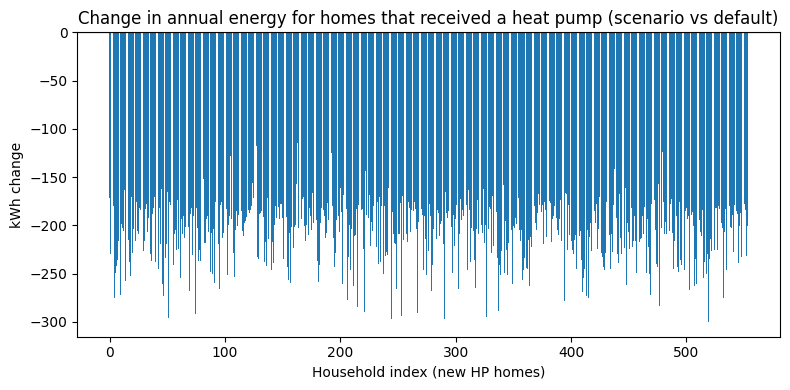

In [55]:
# Plot change
plt.figure(figsize=(8,4))
plt.bar(range(len(delta)), delta["change"], color="tab:blue")
plt.axhline(0, color="k", linewidth=0.8)
plt.title("Change in annual energy for homes that received a heat pump (scenario vs default)")
plt.xlabel("Household index (new HP homes)")
plt.ylabel("kWh change")
plt.tight_layout()
plt.show()

In [56]:
print(m_scenario.config.meta)                # name/date/notes
print(m_scenario.config.model.get("heatpump_adoption_rate"))
print(m_scenario.config.model.get("apply_structural_multipliers"))


{'name': 'heat_pump_scenario', 'date': '2025-11-18', 'notes': 'heat pump adoption scenario for testing, 30% adoption rate'}
0.3
True


In [24]:
from pathlib import Path, PurePath
cfg_path = Path("test_levers.yaml")
print(cfg_path.resolve(), cfg_path.exists())
print(cfg_path.read_text().splitlines()[:40])


/Users/abeltran/Documents/GitHub/spdt_abm/notebooks/test_levers.yaml True
['meta:', '  name: my_demo', "  date: '2025-11-18'", '  notes: Baseline placeholders; replace with SAP/EDRP/SMETER-derived values.', 'model:', '  local_tz: Europe/London', '  heating_setpoint_C: 18.5', '  cooling_threshold_C: 24.0', '  heating_slope_kWh_per_deg: 0.05', '  cooling_slope_kWh_per_deg: 0.03', '  energy_per_person_home: 0.06', '  energy_per_person_away: 0.01', '  setpoint_setback_C: 2.0', '  holiday_prob_daily: 0.002', '  boiler_efficiency: 0.9', '  heatpump_cop_ref: 2.8', '  heatpump_adoption_rate: 0.0', '  heatpump_class_weight:', '    priority: 1.4', '    possible: 1.0', '    difficult: 0.6', '    non-possible: 0.0', '  apply_structural_multipliers: true', 'archetypes:', '  detached:', '    ua_mult: 1.2', '    area_mult_cap:', '    - 0.7', '    - 1.6', '    infiltration_mult: 1.1', '    thermal_mass_class: medium', '  semi-detached:', '    ua_mult: 1.05', '    area_mult_cap:', '    - 0.7', '    - 1

In [57]:
def hp_counts(model):
    was_hp = sum(h.was_heatpump_initial for h in model.household_agents)
    now_hp = sum(h.has_heatpump for h in model.household_agents)
    return was_hp, now_hp

print("default HPs:", hp_counts(m_default))
print("scenario HPs:", hp_counts(m_scenario))

# Adoption rate in use
print("adoption_rate used:", m_scenario.heatpump_adoption_rate)


default HPs: (11, 11)
scenario HPs: (11, 565)
adoption_rate used: 0.3


In [26]:
import pandas as pd
cands = pd.DataFrame([
    {"uid": h.unique_id,
     "cand": getattr(h, "is_heatpump_candidate", 0),
     "cls": getattr(h, "heatpump_candidate_class", None),
     "was_hp": h.was_heatpump_initial}
    for h in m_scenario.household_agents
])
print(cands["cand"].sum(), cands[cands["cand"]==1]["cls"].value_counts())


1847 cls
possible    1571
priority     276
Name: count, dtype: int64


            annual_saving_kwh  annual_saving_gbp  payback_years
AgentID                                                        
4510000410         111.728981          29.440587     101.900143
4510094920         120.933858          31.866072      94.144017
4510089233         130.859658          34.481520      87.003125
4510077524          93.331690          24.592900     121.986425
4510027687         158.706836          41.819251      71.737296


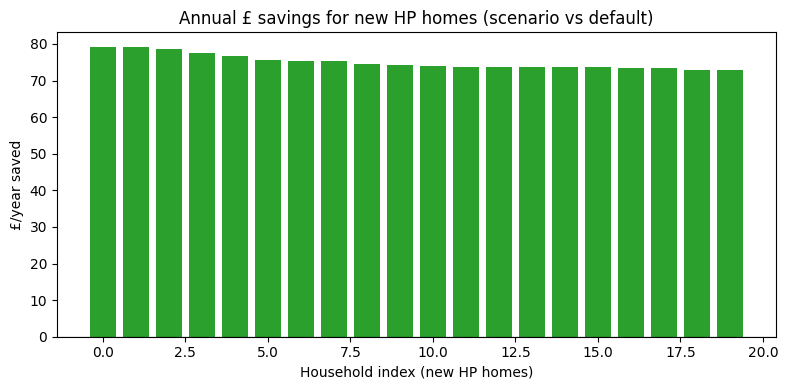

Median £ saving: 38.044037132948326
Median payback (years): 78.85598443499119


In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Tariffs from user (p/kWh → £/kWh)
ELEC_TARIFF = 0.2635
GAS_TARIFF  = 0.0629
ELECTRIC_SHARE = 1.0   # set <1.0 if some displaced energy was gas
hp_capex = 8000        # £, edit
grant    = 5000        # £, edit

blended_tariff = ELEC_TARIFF * ELECTRIC_SHARE + GAS_TARIFF * (1 - ELECTRIC_SHARE)

delta = delta.assign(
    annual_saving_kwh = -delta["change"],               # + means saving
    annual_saving_gbp = -delta["change"] * blended_tariff
)

net_capex = hp_capex - grant
delta["payback_years"] = np.where(
    delta["annual_saving_gbp"] > 0,
    net_capex / delta["annual_saving_gbp"],
    np.inf
)

print(delta[["annual_saving_kwh","annual_saving_gbp","payback_years"]].head())

top = delta.sort_values("annual_saving_gbp", ascending=False).head(20)
plt.figure(figsize=(8,4))
plt.bar(range(len(top)), top["annual_saving_gbp"], color="tab:green")
plt.axhline(0, color="k", lw=0.8)
plt.title("Annual £ savings for new HP homes (scenario vs default)")
plt.xlabel("Household index (new HP homes)")
plt.ylabel("£/year saved")
plt.tight_layout()
plt.show()

print("Median £ saving:", delta["annual_saving_gbp"].median())
print("Median payback (years):", delta.loc[np.isfinite(delta["payback_years"]), "payback_years"].median())


In [81]:
import pandas as pd, numpy as np

# Tariffs (£/kWh) and costs
ELEC_TARIFF = 0.2635
GAS_TARIFF  = 0.0629
ELEC_SHARE  = 0.4      # assume 40% displaced elec, 60% displaced gas
hp_capex = 8000
grant    = 5000
blended_tariff = ELEC_TARIFF*ELEC_SHARE + GAS_TARIFF*(1-ELEC_SHARE)
net_capex = hp_capex - grant

def annual_household_energy(df_agent):
    df = df_agent[df_agent["agent_type"].str.lower() == "household"].copy()
    return df.groupby("AgentID")["energy_consumption"].sum()


# Savings for candidate homes that were not HP initially
m_base = m_default
df_base = df_agent_default 
m_hp = m_scenario
df_hp = df_agent_scenario

base_energy = annual_household_energy(df_base)
hp_energy   = annual_household_energy(df_hp)

hp_status = pd.DataFrame({
    "uid": [h.unique_id for h in m_hp.household_agents],
    "was_hp": [h.was_heatpump_initial for h in m_hp.household_agents],
    "is_hp":  [h.has_heatpump for h in m_hp.household_agents],
    "cand":   [getattr(h, "is_heatpump_candidate", 0) for h in m_hp.household_agents],
})

new_hp_uids = hp_status.query("cand == 1 and was_hp == False and is_hp == True")["uid"]
delta = (hp_energy.loc[new_hp_uids].rename("hp")
         .to_frame()
         .join(base_energy.loc[new_hp_uids].rename("base"))
         .assign(change=lambda d: d["hp"] - d["base"]))  # negative = saving

delta = delta.assign(
    annual_saving_kwh = -delta["change"],
    annual_saving_gbp = -delta["change"] * blended_tariff,
    payback_years = lambda d: np.where(d["annual_saving_gbp"]>0, net_capex / d["annual_saving_gbp"], np.inf)
)

# Top candidates by £ saved
ranked = delta.sort_values("annual_saving_gbp", ascending=False)
print(ranked.head())




                     hp         base      change  annual_saving_kwh  \
AgentID                                                               
4510723899  2875.370546  3175.963801 -300.593255         300.593255   
4510717036  2088.193528  2388.632592 -300.439064         300.439064   
4510722309  3632.154400  3930.587298 -298.432899         298.432899   
4510722304  1751.158436  2045.698867 -294.540431         294.540431   
4510724727  3537.784492  3828.995632 -291.211140         291.211140   

            annual_saving_gbp  payback_years  
AgentID                                       
4510723899          43.026919      69.723794  
4510717036          43.004848      69.759578  
4510722309          42.717685      70.228525  
4510722304          42.160517      71.156622  
4510724727          41.683963      71.970125  


<Axes: title={'center': 'Top HP candidates by £/year saved'}, xlabel='AgentID'>

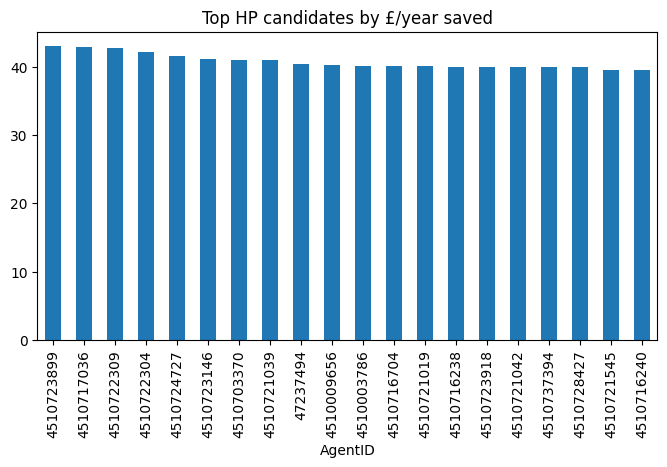

In [82]:
ranked.head(20)["annual_saving_gbp"].plot(kind="bar", figsize=(8,4), title="Top HP candidates by £/year saved")

In [83]:
# Pull SAP for those UIDs
sap_map = gdf_small.set_index("UPRN" or "uid_column")["sap_rating"]  # adjust index to match AgentID/uid
delta = delta.join(sap_map.rename("sap"), how="left")

# Option A: filter to low SAP then rank by £ saving
low_sap = delta[delta["sap"] < 55].sort_values("annual_saving_gbp", ascending=False)
low_sap



,hp,base,change,annual_saving_kwh,annual_saving_gbp,payback_years,sap
AgentID,,,,,,,
4510703370,11732.157319,12018.562303,-286.404984,286.404984,40.996009,73.177854,51
4510009656,20511.434083,20793.031249,-281.597166,281.597166,40.307818,74.427248,30
4510003786,3772.413263,4052.615902,-280.202639,280.202639,40.108206,74.797661,40
4510045083,3048.960088,3315.296888,-266.336801,266.336801,38.123450,78.691725,38
4510705366,4839.951922,5095.291489,-255.339567,255.339567,36.549306,82.080903,51
...,...,...,...,...,...,...,...
4510011414,715.069916,782.058913,-66.988997,66.988997,9.588805,312.864844,45
4510703424,535.373746,601.781493,-66.407747,66.407747,9.505605,315.603272,54
4510730785,483.615576,549.221255,-65.605680,65.605680,9.390797,319.461703,43


In [92]:
# pick the ID that matches your AgentID index
id_col = "UPRN"  # change if AgentID is something else

cols = [
    "sap_rating", "property_type", "property_age", "main_fuel_type", "main_heating_system",
    "floor_area_m2", "is_off_gas", "is_gas", "is_electric_heating",
    "retrofit_envelope_score"
]

attr = gdf_small.set_index(id_col)[cols]
summary = (delta
           .join(attr, how="left")  # delta index should match id_col/AgentID
           .sort_values("annual_saving_gbp", ascending=False))

print(summary.head(10)[[
    "annual_saving_kwh", "annual_saving_gbp", "payback_years",
    "sap_rating", "property_type", "property_age", "main_fuel_type",
    "main_heating_system", "floor_area_m2", 
    "is_off_gas", "is_gas", "is_electric_heating", "retrofit_envelope_score"
]])


            annual_saving_kwh  annual_saving_gbp  payback_years  sap_rating  \
AgentID                                                                       
4510723899         300.593255          43.026919      69.723794          78   
4510717036         300.439064          43.004848      69.759578          76   
4510722309         298.432899          42.717685      70.228525          79   
4510722304         294.540431          42.160517      71.156622          77   
4510724727         291.211140          41.683963      71.970125          79   
4510723146         287.416832          41.140845      72.920232          77   
4510703370         286.404984          40.996009      73.177854          51   
4510721039         286.148617          40.959313      73.243416          74   
47237494           282.782429          40.477477      74.115292          79   
4510009656         281.597166          40.307818      74.427248          30   

             property_type property_age main_fuel_t

In [94]:
print(summary.groupby("property_type")[["annual_saving_gbp","sap_rating"]].median())


                                                    annual_saving_gbp  \
property_type                                                           
detached house                                              30.889272   
end-terraced house                                          21.873696   
large block of flats                                        10.248515   
mid-terraced house                                          20.523088   
semi-detached house                                         20.724126   
small block of flats/dwelling converted in to f...          11.806945   

                                                    sap_rating  
property_type                                                   
detached house                                            76.0  
end-terraced house                                        72.0  
large block of flats                                      76.0  
mid-terraced house                                        70.0  
semi-detached house      

In [95]:
print(summary.groupby(pd.cut(summary["sap_rating"], [0,55,65,100]))["annual_saving_gbp"].median())


sap_rating
(0, 55]      21.439229
(55, 65]     19.377078
(65, 100]    21.054594
Name: annual_saving_gbp, dtype: float64


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_91725/3870359823.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(summary.groupby(pd.cut(summary["sap_rating"], [0,55,65,100]))["annual_saving_gbp"].median())


In [98]:
import ipywidgets as w
from IPython.display import display

prop_options = ["(all)"] + sorted(summary["property_type"].dropna().unique().tolist())
sap_min, sap_max = float(summary["sap_rating"].min()), float(summary["sap_rating"].max())
gbp_min, gbp_max = summary["annual_saving_gbp"].min(), summary["annual_saving_gbp"].max()

prop_dd = w.Dropdown(options=prop_options, value="(all)", description="Property")
sap_slider = w.FloatRangeSlider(value=[sap_min, sap_max], min=sap_min, max=sap_max,
                                step=1, description="SAP range")
gbp_slider = w.FloatRangeSlider(value=[gbp_min, gbp_max], min=gbp_min, max=gbp_max,
                                step=max(1, (gbp_max-gbp_min)/100), description="£/yr saving")

def show_table(prop, sap_range, gbp_range):
    df = summary.copy()
    if prop != "(all)":
        df = df[df["property_type"] == prop]
    df = df[df["sap_rating"].between(*sap_range)]
    df = df[df["annual_saving_gbp"].between(*gbp_range)]
    display(df.head(200)[[
        "annual_saving_kwh", "annual_saving_gbp", "payback_years",
        "sap_rating", "property_type", "property_age", "main_fuel_type",
        "main_heating_system", "floor_area_m2", 
        "is_off_gas", "is_gas", "is_electric_heating", "retrofit_envelope_score"
    ]])

ui = w.VBox([prop_dd, sap_slider, gbp_slider])
out = w.interactive_output(show_table, {"prop": prop_dd, "sap_range": sap_slider, "gbp_range": gbp_slider})
display(ui, out)


Output()

In [ ]:
# Install if needed (run once);
# in a notebook you can do: !pip install ipydatagrid
import ipydatagrid as dg
import ipywidgets as w
from IPython.display import display

prop_options = ["(all)"] + sorted(summary["property_type"].dropna().unique().tolist())
sap_min, sap_max = float(summary["sap_rating"].min()), float(summary["sap_rating"].max())
gbp_min, gbp_max = summary["annual_saving_gbp"].min(), summary["annual_saving_gbp"].max()

prop_dd = w.Dropdown(options=prop_options, value="(all)", description="Property")
sap_slider = w.FloatRangeSlider(value=[sap_min, sap_max], min=sap_min, max=sap_max, step=1, description="SAP range")
gbp_slider = w.FloatRangeSlider(value=[gbp_min, gbp_max], min=gbp_min, max=gbp_max,
                                step=max(1, (gbp_max-gbp_min)/100), description="£/yr saving")

show_cols = [
    "annual_saving_kwh", "annual_saving_gbp", "payback_years",
    "sap_rating", "property_type", "property_age", "main_fuel_type",
    "main_heating_system", "floor_area_m2", 
    "is_off_gas", "is_gas", "is_electric_heating", "retrofit_envelope_score"
]

def show_table(prop, sap_range, gbp_range):
    df = summary.copy()
    if prop != "(all)":
        df = df[df["property_type"] == prop]
    df = df[df["sap_rating"].between(*sap_range)]
    df = df[df["annual_saving_gbp"].between(*gbp_range)]
    view = df.reset_index()[show_cols]  # reset index so it shows up as a column
    grid = dg.DataGrid(
        view,
        layout={"height": "650px"},
        selection_mode="row",
        base_row_size=26,
        auto_fit_columns=True,   # set the flag here
    )
    display(grid)


ui = w.VBox([prop_dd, sap_slider, gbp_slider])
out = w.interactive_output(show_table, {"prop": prop_dd, "sap_range": sap_slider, "gbp_range": gbp_slider})
display(ui, out)


Output()